<a href="https://colab.research.google.com/github/DylanSanchz/Quantum-Circuits/blob/main/Deutsch_Jozsa_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install 'qiskit [visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 107.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=6c2364e03eafa55f39d93d26b1b02bcc5d97bdb0f0a243a05045f88835db0a67
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00


Importamos las librerias

In [ ]:
from qiskit import QuantumCircuit, transpile
#from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

Crear circuito cuantico

Para un UF=NOT

In [ ]:
# Definimos el circuito
qc_0= QuantumCircuit(2,1)


# Puerta NOT en el segundo qbit
qc_0.x(1)
qc_0.barrier()

# Aplicamos Hadamard en ambos qbits
qc_0.h(0)
qc_0.h(1)
qc_0.barrier()

# FUNCION UF
qc_0.x(1)   # EN ESTE CASO ES UN NOT
qc_0.barrier()

# Hadamard en la primera linea (de nuevo)
qc_0.h(0)
#qc.h(1)
qc_0.barrier()
# Medición
qc_0.measure(0,0)

# Dibujamos el resultado
print(qc_0.draw())

           ░ ┌───┐ ░       ░ ┌───┐ ░ ┌─┐
q_0: ──────░─┤ H ├─░───────░─┤ H ├─░─┤M├
     ┌───┐ ░ ├───┤ ░ ┌───┐ ░ └───┘ ░ └╥┘
q_1: ┤ X ├─░─┤ H ├─░─┤ X ├─░───────░──╫─
     └───┘ ░ └───┘ ░ └───┘ ░       ░  ║ 
c: 1/═════════════════════════════════╩═
                                      0 


In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_0, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'0': 1024}


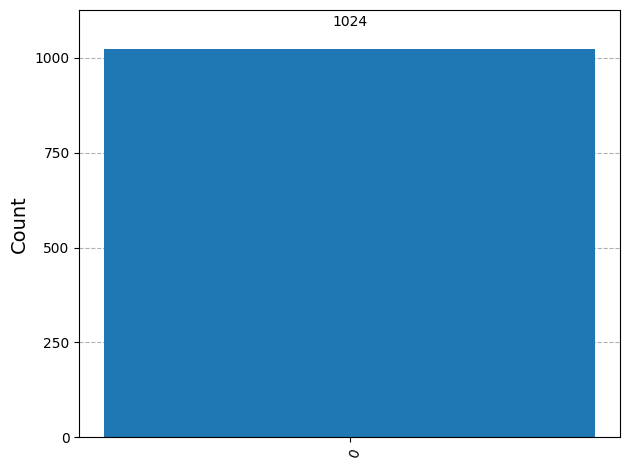

In [ ]:
hist = plot_histogram(counts)
display(hist)

PARA 2 QBITS EN LA PRIMERA LINEA

In [ ]:
# Definimos el circuito
qc_1= QuantumCircuit(2,1)


# Puerta NOT en el segundo qbit
qc_1.x(1)
qc_1.barrier()

# Aplicamos Hadamard en ambos qbits
qc_1.h(0)
qc_1.h(1)
qc_1.barrier()

# FUNCION UF
qc_1.cz(0,1)   # EN ESTE CASO ES UN CNOT
qc_1.barrier()

# Hadamard en la primera linea (de nuevo)
qc_1.h(0)
#qc.h(1)
qc_1.barrier()
# Medición
qc_1.measure(0,0)

# Dibujamos el resultado
print(qc_1.draw())

           ░ ┌───┐ ░     ░ ┌───┐ ░ ┌─┐
q_0: ──────░─┤ H ├─░──■──░─┤ H ├─░─┤M├
     ┌───┐ ░ ├───┤ ░  │  ░ └───┘ ░ └╥┘
q_1: ┤ X ├─░─┤ H ├─░──■──░───────░──╫─
     └───┘ ░ └───┘ ░     ░       ░  ║ 
c: 1/═══════════════════════════════╩═
                                    0 


In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_1, simulator)

result = simulator.run(compiled, shots=8192).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'0': 4035, '1': 4157}


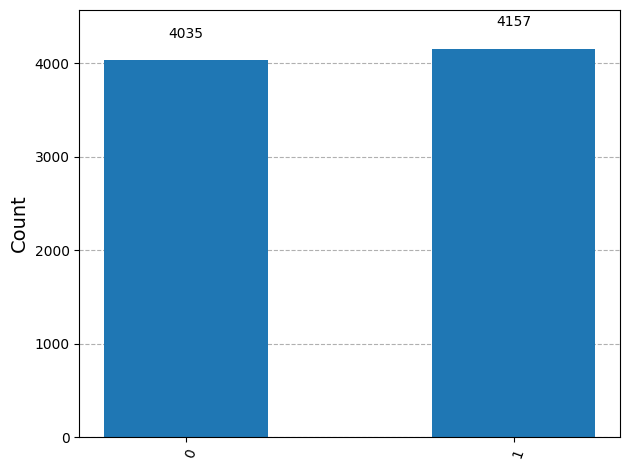

In [ ]:
hist = plot_histogram(counts)
display(hist)

In [ ]:
#Creamos el circuito
qc_2 = QuantumCircuit(3,1)

#Qbit auxiliar

qc_2.x(2)
qc_2.barrier()

# Aplicamos Hadamard en todas

qc_2.h(0)
qc_2.h(1)
qc_2.h(2)
qc_2.barrier()

#FUNCION UF

qc_2.x(2)
qc_2.barrier()

#Aplicamos Hadamard de nuevo

qc_2.h(0)
qc_2.h(1)
qc_2.h(2)

# Medición
qc_2.measure(0,0)

# Dibujamos el resultado
print(qc_2.draw())





           ░ ┌───┐ ░       ░ ┌───┐┌─┐
q_0: ──────░─┤ H ├─░───────░─┤ H ├┤M├
           ░ ├───┤ ░       ░ ├───┤└╥┘
q_1: ──────░─┤ H ├─░───────░─┤ H ├─╫─
     ┌───┐ ░ ├───┤ ░ ┌───┐ ░ ├───┤ ║ 
q_2: ┤ X ├─░─┤ H ├─░─┤ X ├─░─┤ H ├─╫─
     └───┘ ░ └───┘ ░ └───┘ ░ └───┘ ║ 
c: 1/══════════════════════════════╩═
                                   0 


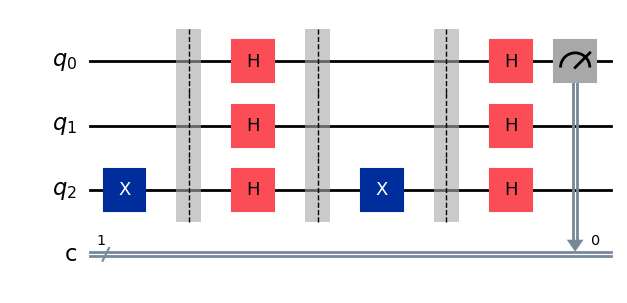

In [ ]:
qc_2.draw("mpl", filename="quantum_circuit.png")

In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_2, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'0': 1024}


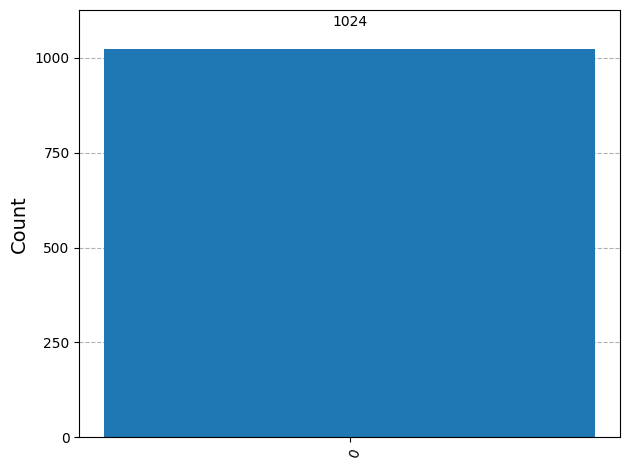

In [ ]:
hist = plot_histogram(counts)
display(hist)

In [ ]:
#Creamos el circuito
qc_3 = QuantumCircuit(3,2)

#Qbit auxiliar

qc_3.x(2)
qc_3.barrier()

# Aplicamos Hadamard en todas

qc_3.h(0)
qc_3.h(1)
qc_3.h(2)
qc_3.barrier()

#FUNCION UF

qc_3.cx(0,2)  #PUERTA CNOT (Tener en cuenta el Qbit auxiliar)
qc_3.barrier()

#Aplicamos Hadamard de nuevo

qc_3.h(0)
qc_3.h(1)
qc_3.h(2)

# Medición
qc_3.measure(0,0)
qc_3.measure(1,1)

# Dibujamos el resultado
print(qc_3.draw())

           ░ ┌───┐ ░       ░ ┌───┐┌─┐   
q_0: ──────░─┤ H ├─░───■───░─┤ H ├┤M├───
           ░ ├───┤ ░   │   ░ ├───┤└╥┘┌─┐
q_1: ──────░─┤ H ├─░───┼───░─┤ H ├─╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐ ░ ├───┤ ║ └╥┘
q_2: ┤ X ├─░─┤ H ├─░─┤ X ├─░─┤ H ├─╫──╫─
     └───┘ ░ └───┘ ░ └───┘ ░ └───┘ ║  ║ 
c: 2/══════════════════════════════╩══╩═
                                   0  1 


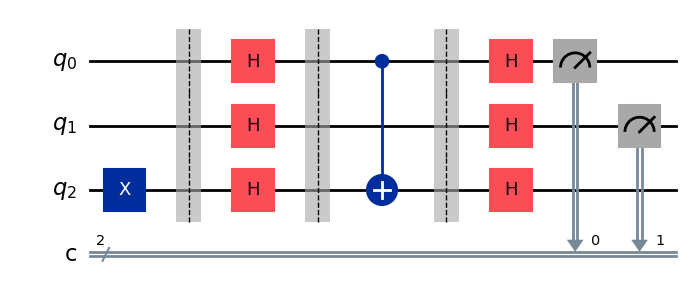

In [ ]:
qc_3.draw("mpl", filename="quantum_circuit.png")

In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_3, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'01': 1024}


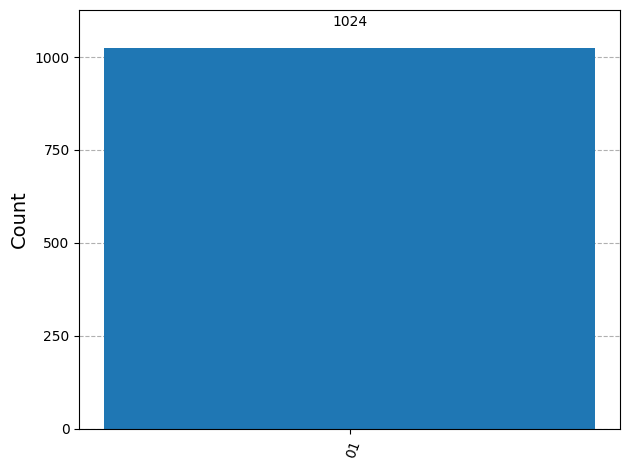

In [ ]:
hist = plot_histogram(counts)
display(hist)

In [ ]:
#Creamos el circuito
qc_4 = QuantumCircuit(3,2)

#Qbit auxiliar

qc_4.x(2)
qc_4.barrier()

# Aplicamos Hadamard en todas

qc_4.h(0)
qc_4.h(1)
qc_4.h(2)
qc_4.barrier()

#FUNCION UF

qc_4.cx(1,2)  #PUERTA CNOT (Tener en cuenta el Qbit auxiliar)
qc_4.barrier()

#Aplicamos Hadamard de nuevo

qc_4.h(0)
qc_4.h(1)
qc_4.h(2)

# Medición
qc_4.measure(0,0)
qc_4.measure(1,1)
# Dibujamos el resultado
print(qc_4.draw())

           ░ ┌───┐ ░       ░ ┌───┐┌─┐   
q_0: ──────░─┤ H ├─░───────░─┤ H ├┤M├───
           ░ ├───┤ ░       ░ ├───┤└╥┘┌─┐
q_1: ──────░─┤ H ├─░───■───░─┤ H ├─╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐ ░ ├───┤ ║ └╥┘
q_2: ┤ X ├─░─┤ H ├─░─┤ X ├─░─┤ H ├─╫──╫─
     └───┘ ░ └───┘ ░ └───┘ ░ └───┘ ║  ║ 
c: 2/══════════════════════════════╩══╩═
                                   0  1 


In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_4, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'10': 1024}


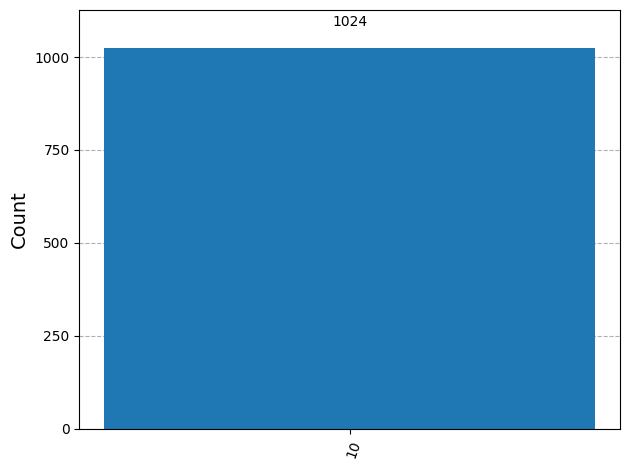

In [ ]:
hist = plot_histogram(counts)
display(hist)

In [ ]:
#Creamos el circuito
qc_5 = QuantumCircuit(3,2)

#Qbit auxiliar

qc_5.x(2)
qc_5.barrier()

# Aplicamos Hadamard en todas

qc_5.h(0)
qc_5.h(1)
qc_5.h(2)
qc_5.barrier()

#FUNCION UF

qc_5.cx(1,2)  #PUERTA CNOT (Tener en cuenta el Qbit auxiliar)
qc_5.cx(0,2)
qc_5.barrier()

#Aplicamos Hadamard de nuevo

qc_5.h(0)
qc_5.h(1)
qc_5.h(2)

# Medición
qc_5.measure(0,0)
qc_5.measure(1,1)
# Dibujamos el resultado
print(qc_5.draw())

           ░ ┌───┐ ░            ░ ┌───┐┌─┐   
q_0: ──────░─┤ H ├─░────────■───░─┤ H ├┤M├───
           ░ ├───┤ ░        │   ░ ├───┤└╥┘┌─┐
q_1: ──────░─┤ H ├─░───■────┼───░─┤ H ├─╫─┤M├
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐ ░ ├───┤ ║ └╥┘
q_2: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├─░─┤ H ├─╫──╫─
     └───┘ ░ └───┘ ░ └───┘└───┘ ░ └───┘ ║  ║ 
c: 2/═══════════════════════════════════╩══╩═
                                        0  1 


In [ ]:
simulator = AerSimulator()

compiled = transpile(qc_5, simulator)

result = simulator.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)
plt.show()

Counts: {'11': 1024}


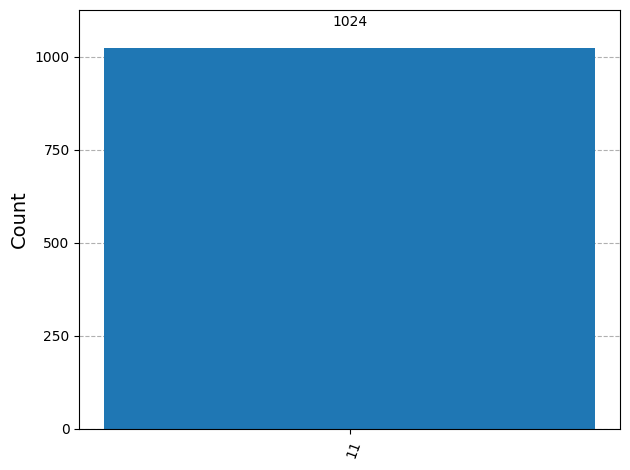

In [ ]:
hist = plot_histogram(counts)
display(hist)